In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

# Load dataset
df = pd.read_csv("data/prosperLoanData.csv")

In [3]:
df.head()

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,...,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
0,1021339766868145413AB3B,193129,2007-08-26 19:09:29.263000000,C,36,Completed,2009-08-14 00:00:00,0.16516,0.1580,0.1380,...,-133.18,0.0,0.0,0.0,0.0,1.0,0,0,0.0,258
1,10273602499503308B223C1,1209647,2014-02-27 08:28:07.900000000,NaN,36,Current,NaN,0.12016,0.0920,0.0820,...,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1
2,0EE9337825851032864889A,81716,2007-01-05 15:00:47.090000000,HR,36,Completed,2009-12-17 00:00:00,0.28269,0.2750,0.2400,...,-24.20,0.0,0.0,0.0,0.0,1.0,0,0,0.0,41
3,0EF5356002482715299901A,658116,2012-10-22 11:02:35.010000000,NaN,36,Current,NaN,0.12528,0.0974,0.0874,...,-108.01,0.0,0.0,0.0,0.0,1.0,0,0,0.0,158
4,0F023589499656230C5E3E2,909464,2013-09-14 18:38:39.097000000,NaN,36,Current,NaN,0.24614,0.2085,0.1985,...,-60.27,0.0,0.0,0.0,0.0,1.0,0,0,0.0,20


In [4]:
# Select relevant columns (modify based on dataset)
columns_to_use = ["CreditScoreRangeLower", "StatedMonthlyIncome", "LoanOriginalAmount", "LoanStatus"]
df = df[columns_to_use].dropna()

# Convert categorical loan status into a binary classification:
# 'Completed' and 'Current' are considered as "Good" (1), others as "Bad" (0)
df["LoanStatus"] = df["LoanStatus"].apply(lambda x: 1 if x in ["Completed", "Current"] else 0)

# Feature Scaling
scaler = StandardScaler()
df[["CreditScoreRangeLower", "StatedMonthlyIncome", "LoanOriginalAmount"]] = scaler.fit_transform(
    df[["CreditScoreRangeLower", "StatedMonthlyIncome", "LoanOriginalAmount"]])

# Split data into training and testing sets
X = df[["CreditScoreRangeLower", "StatedMonthlyIncome", "LoanOriginalAmount"]]
y = df["LoanStatus"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
df["log_reg_score"] = log_reg.predict_proba(X)[:, 1]

# Train LightGBM
lgb_train = lgb.Dataset(X_train, label=y_train)
params = {"objective": "binary", "metric": "binary_logloss", "verbosity": -1}
lgbm = lgb.train(params, lgb_train, num_boost_round=100)
df["lgbm_score"] = lgbm.predict(X)

# Hybrid Score (weighted combination)
df["final_score"] = 0.3 * df["log_reg_score"] + 0.7 * df["lgbm_score"]

# Decision Logic
def loan_decision(score):
    if score < 0.3:
        return "✅ Approve"
    elif score < 0.6:
        return "⚠️ Review"
    else:
        return "❌ Reject"

df["decision"] = df["final_score"].apply(loan_decision)

# Save processed dataset
df.to_csv("processed_loans.csv", index=False)

print("✅ Data Processed Successfully!")


✅ Data Processed Successfully!


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


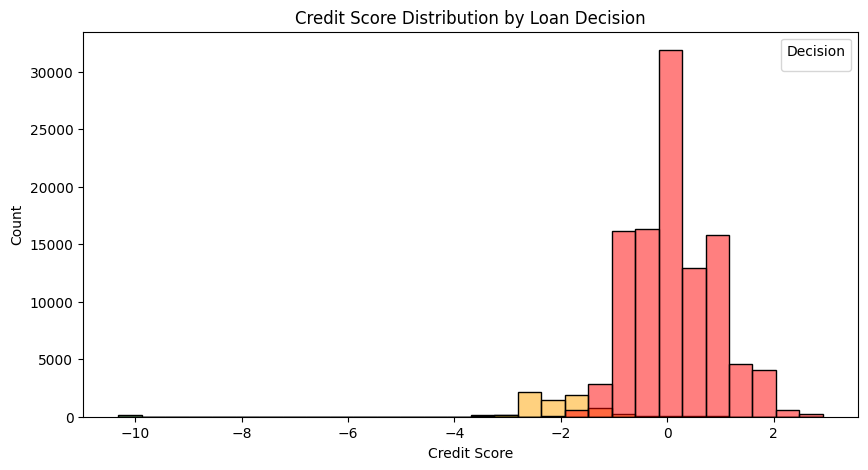

/Users/robbieardison/anaconda3/envs/tf-pro/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/robbieardison/anaconda3/envs/tf-pro/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


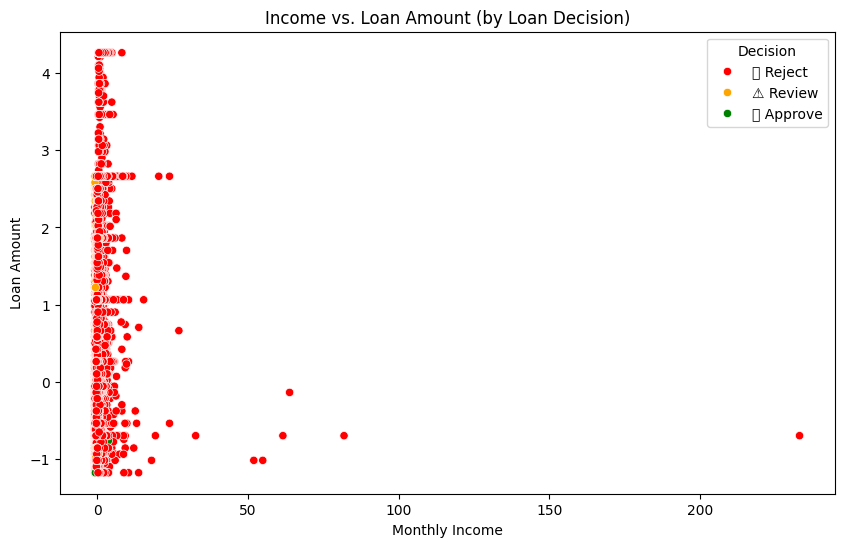

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


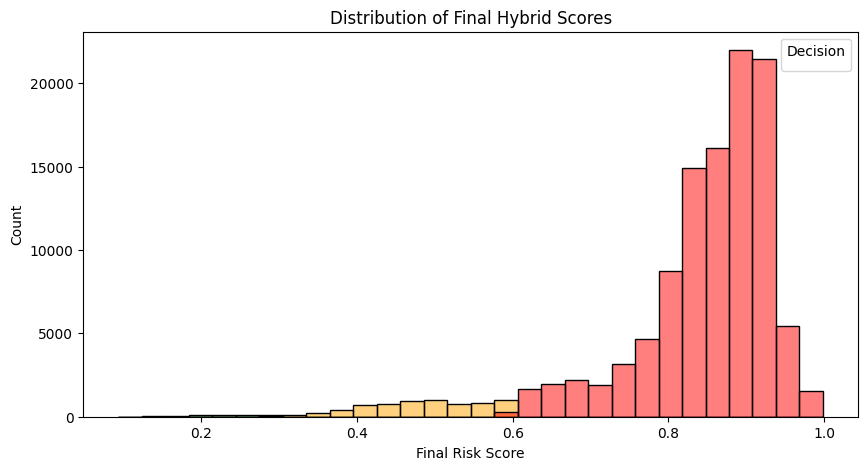

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load processed dataset
df = pd.read_csv("processed_loans.csv")

# Set color palette
color_map = {"✅ Approve": "green", "⚠️ Review": "orange", "❌ Reject": "red"}

# Histogram of Credit Scores
plt.figure(figsize=(10, 5))
sns.histplot(df, x="CreditScoreRangeLower", hue="decision", palette=color_map, bins=30)
plt.title("Credit Score Distribution by Loan Decision")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.legend(title="Decision")
plt.show()

# Scatter plot: Income vs. Loan Amount
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="StatedMonthlyIncome", y="LoanOriginalAmount", hue="decision", palette=color_map)
plt.title("Income vs. Loan Amount (by Loan Decision)")
plt.xlabel("Monthly Income")
plt.ylabel("Loan Amount")
plt.legend(title="Decision")
plt.show()

# Final Score Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df, x="final_score", hue="decision", palette=color_map, bins=30)
plt.title("Distribution of Final Hybrid Scores")
plt.xlabel("Final Risk Score")
plt.ylabel("Count")
plt.legend(title="Decision")
plt.show()
